# 19 · Part of a whole, and the grid — pie, donut, funnel area, funnel, treemap, heatmap, matrix, KPI, combo

**Use case.** The nine chart types that are not a bar and not a line. Each one answers a question the bar family cannot, and each one has a rule that follows from what it means: a composition has no Top N because truncating a whole is a lie about it, a funnel has an order because the order IS the funnel, a heatmap has cell caps because a grid loses whole rows rather than a tail, and a KPI has no axis and therefore no drill. With this chapter the book has covered all 24.

**What you will learn**
1. `pie` · `donut` · `funnelarea` — one additive whole, and why none of them takes a Top N
2. `funnel` — the one composition that is ordered by its measure, with no limit
3. `treemap` — 426 leaves against a 200-leaf bound, and what the engine does about it
4. `heatmap` and `matrix` — two axes and a value; `series` is the y channel, not a legend
5. `kpi` — one number over the whole filtered table, and why `charts.kpi(charts.count())` alone refuses
6. `combo` — two measures, one axis, a real second y-axis, and why a legend is refused
7. The three surfaces this server has switched off, as code you can copy

**What this costs.** nothing.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, credits_used, save_metrics, show, fig, fresh_tab, spend, show_recipe
from langsat import charts, viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'Langsat_SDK' with 21 scopes


In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)
tab = fresh_tab(p, "19 · Composition")
cap = tab.builder_capabilities()
FACT = "review"
def edge(dim):
    fk = next(c for c, t in cap["joins"]["foreign_keys"][FACT].items() if t == dim)
    return {"table": dim, "left_column": fk, "right_column": cap["joins"]["primary_keys"][dim], "type": "left"}
TO_PRODUCT, TO_CUSTOMER = [edge("product")], [edge("customer")]

reusing project 5c40e337-9753-4618-a7b3-574419f93c1e (amazon-reviews-explore, status=schema_done)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
already cleaned — skipping
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


## 1 · One additive whole

`pie`, `donut` and `funnelarea` are three drawings of the same idea: these parts sum to something, and each part's
share of it is the message. `donut` is a `pie` with `hole: 0.4` — the hole is not decoration, it removes the centre
where a pie's angles are hardest to compare and leaves the arc lengths, which are easier.

None of the three has a `top_n` parameter, and the reason is arithmetic rather than taste: keep 50 of 1,200 slices
and every remaining slice's implied share is wrong, because the reader computes it against a whole that is no longer
there. If you need to narrow a composition, **filter** — then the whole is the thing you filtered to, and the shares
are true of it.

In [3]:
import inspect
for cid in ("pie", "donut", "funnelarea", "funnel", "treemap"):
    ps = set(inspect.signature(getattr(charts, cid)).parameters)
    print(f"  charts.{cid:<12} top_n {'yes' if 'top_n' in ps else 'no '}  "
          f"top_n_dir {'yes' if 'top_n_dir' in ps else 'no '}  details {'yes' if 'details' in ps else 'no '}")

  charts.pie          top_n no   top_n_dir no   details yes
  charts.donut        top_n no   top_n_dir no   details yes
  charts.funnelarea   top_n no   top_n_dir no   details no 
  charts.funnel       top_n no   top_n_dir yes  details no 
  charts.treemap      top_n no   top_n_dir no   details yes


In [4]:
for cid, title in [("pie", "Share of reviews by rating"),
                   ("donut", "Share of reviews by rating (donut)"),
                   ("funnelarea", "Rating mix, as a funnel area")]:
    pv = tab.preview_chart(getattr(charts, cid)(axis="review.rating", value=charts.count(), tables=["review"]))
    _ = tab.add_chart(pv["recipe"], title=title)
    d0 = pv["spec"]["data"][0]
    print(f"{cid:<12} trace={d0['type']:<11}{' hole=' + str(d0['hole']) if d0.get('hole') else ''}"
          f" · labels={d0.get('labels')} values={d0.get('values')}")

pie          trace=pie         · labels=[1, 2, 3, 4, 5] values=[282, 358, 850, 2199, 6311]


donut        trace=pie         hole=0.4 · labels=[1, 2, 3, 4, 5] values=[282, 358, 850, 2199, 6311]


funnelarea   trace=funnelarea  · labels=[1, 2, 3, 4, 5] values=[282, 358, 850, 2199, 6311]


## 2 · `funnel` — the order *is* the chart

A funnel is a composition whose stages are meant to descend. Plotly has no `sort` for it, so without an explicit
order the engine falls through to `ORDER BY d0` — alphabetical — and 1,000 / 400 / 120 comes back 400 → 120 → 1,000:
a funnel that narrows and then balloons, with every percent-of-first read off the wrong stage.

So `charts.funnel` is the one composition that emits an `order_by` — a **direction with no limit**. `top_n_dir`
exists here and nowhere else in the family, because here the direction means something.

In [5]:
f = charts.funnel(axis="review.rating", value=charts.count(), tables=["review"])
print("order_by:", f["order_by"], "· limit present?", "limit" in f["order_by"])
pv = tab.preview_chart(f)
_ = tab.add_chart(pv["recipe"], title="Ratings as a funnel")
print("stages as drawn:", list(zip(pv["spec"]["data"][0]["y"], pv["spec"]["data"][0]["x"])))

order_by: {'dir': 'desc'} · limit present? False


stages as drawn: [(5, 6311), (4, 2199), (3, 850), (2, 358), (1, 282)]


## 3 · `treemap` — and a bound that is a correctness limit

A treemap nests rectangles by area, so it reads a large number of categories far better than a pie can.
`product.category` has 426 distinct values, and this is where a number in the grammar turns out to be advice rather
than a rule: `limits.max_composition_leaves` is 200, and the engine drew all 426 anyway. So read it as the point past
which a treemap stops being legible — which 426 rectangles in a dashboard card certainly is — and narrow it yourself
with a filter. Do not read it as something that will stop you.

In [6]:
t = charts.treemap(axis="product.category", value=charts.count(),
                   tables=["review", "product"], joins=TO_PRODUCT)
pv = tab.preview_chart(t)
_ = tab.add_chart(pv["recipe"], title="Reviews by category, as a treemap")
print("max_composition_leaves:", cap["limits"]["max_composition_leaves"],
      "· n_groups:", pv["n_groups"], "· leaves actually drawn:", len(pv["spec"]["data"][0]["labels"]))
print("biggest three:", sorted(zip(pv["spec"]["data"][0]["values"], pv["spec"]["data"][0]["labels"]), reverse=True)[:3])

legible = tab.preview_chart(charts.treemap(axis="product.category", value=charts.count(),
                                           tables=["review", "product"], joins=TO_PRODUCT,
                                           filters=[charts.contains("product.category", "Mystery")]))
_ = tab.add_chart(legible["recipe"], title="Mystery categories only")
print("\nnarrowed with a filter:", legible["n_groups"], "leaves — and every share is true of that whole")

max_composition_leaves: 200 · n_groups: 426 · leaves actually drawn: 426
biggest three: [(1023, 'Books|Literature &amp; Fiction|Genre Fiction'), (697, 'Books|Mystery, Thriller &amp; Suspense|Thrillers &amp; Suspense'), (482, '\\N')]



narrowed with a filter: 7 leaves — and every share is true of that whole


## 4 · `heatmap` and `matrix` — two axes and a value

These are the only two chart types where **both** fields are axes. The recipe grammar has no second-dimension slot,
so the second one rides in as `role: "series"` and the engine resolves it to the **y channel** rather than to a
legend — which is why `series` is a required positional argument here rather than an optional well.

A `matrix` is the same aggregate drawn as a Plotly `table`: the numbers instead of the colours, which is what you
want when the reader will quote them. Both are bounded by cells rather than by categories, because a grid that is
too big loses whole rows rather than a tail.

In [7]:
for cid, title in [("heatmap", "Ratings by year, as a heatmap"), ("matrix", "Ratings by year, as a table")]:
    r = getattr(charts, cid)(axis=charts.date("review.review_time", "year"), series="review.rating",
                             value=charts.count(), tables=["review"])
    pv = tab.preview_chart(r)
    _ = tab.add_chart(pv["recipe"], title=title)
    d0 = pv["spec"]["data"][0]
    print(f"{cid:<9} trace={d0['type']:<9} · role of the second field: "
          f"{r['group_by'][1].get('role')} · keys={sorted(d0)[:4]}")
print("\nbounds: max_heatmap_series", cap["limits"]["max_heatmap_series"],
      "· max_heatmap_cells", cap["limits"]["max_heatmap_cells"], "· this grid: 11 × 5 = 55 cells")

heatmap   trace=heatmap   · role of the second field: series · keys=['name', 'type', 'x', 'y']


matrix    trace=table     · role of the second field: series · keys=['cells', 'header', 'type']

bounds: max_heatmap_series 50 · max_heatmap_cells 7500 · this grid: 11 × 5 = 55 cells


⚠ **And one asymmetry worth knowing before you build on it.** A card's figure is either written to
object storage with a `data_ref` on the widget — which is what happens to almost everything, `dashcard_offload` —
or kept inline on the widget as `plotly`. `chart.data()` serves the **offloaded** payload, so on an inline card it
answers `400 widget has no offloaded data`. A `matrix` is small by construction and therefore always inline, so its
numbers are read from the widget rather than from the endpoint. Both are free; they are just different doors.

In [8]:
tab.refresh()
by_id = {w.get("id") or w.get("widget_id"): w for w in tab.widgets}
for c in tab.charts:
    w = by_id.get(c.id, {})
    print(f"  {c.title[:36]:<38} inline={bool(w.get('plotly'))}  data_ref={bool(w.get('data_ref'))}")

from langsat.errors import Invalid
try:
    tab.chart("Ratings by year, as a table").data(op="aggregate")
except Invalid as e:
    print(f"\n  chart.data() on the inline card → {e.status} {e.message}")

  Share of reviews by rating             inline=False  data_ref=True
  Share of reviews by rating (donut)     inline=False  data_ref=True
  Rating mix, as a funnel area           inline=False  data_ref=True
  Ratings as a funnel                    inline=False  data_ref=True
  Reviews by category, as a treemap      inline=False  data_ref=True
  Mystery categories only                inline=False  data_ref=True
  Ratings by year, as a heatmap          inline=False  data_ref=True
  Ratings by year, as a table            inline=True  data_ref=True



  chart.data() on the inline card → 400 widget has no offloaded data


In [9]:
cells = by_id[tab.chart("Ratings by year, as a table").id]["plotly"]["data"][0]
pd.DataFrame(dict(zip(cells["header"]["values"][1:], cells["cells"]["values"][1:])),
             index=cells["cells"]["values"][0]).rename_axis("rating")

,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
rating,,,,,,,,,,,
1,4,14,16,19,23,28,49,44,41,35,9
2,10,10,11,17,16,48,69,68,63,35,11
3,14,19,23,28,46,113,159,148,149,112,39
4,35,55,38,66,134,319,424,377,366,299,86
5,65,74,112,132,292,805,1223,1214,1153,966,275


## 5 · `kpi` — one number, no axis, no drill

A KPI is `dimensionless`: it groups by nothing, so the aggregate is defined over the whole filtered table. That is
also why it cannot be drilled — a click would have no category to filter by — and why it emits no `order_by`.

`charts.kpi(charts.count())` on its own is refused locally, and the refusal is worth reading: a count of rows with
no column names no table, so there is nothing to count. Pass `tables=`.

In [10]:
from langsat._charts_core import RecipeError
try:
    charts.kpi(charts.count())
except RecipeError as e:
    print(e)

for label, measure in [("Mean rating", charts.avg("review.rating")),
                       ("Reviews", charts.count()),
                       ("Distinct products reviewed", charts.count_distinct("review.product_id"))]:
    pv = tab.preview_chart(charts.kpi(measure, tables=["review"]))
    _ = tab.add_chart(pv["recipe"], title=label)
    d0 = pv["spec"]["data"][0]
    print(f"  {label:<28} {d0['type']}/{d0['mode']} = {d0['value']:,} · n_groups={pv['n_groups']}")

[countNeedsTable] this recipe names no table — a count of rows with no column to infer one from has to say which table: pass tables=["your_table"]


  Mean rating                  indicator/number = 4.3899 · n_groups=0


  Reviews                      indicator/number = 10,000 · n_groups=0


  Distinct products reviewed   indicator/number = 8,607 · n_groups=0


## 6 · `combo` — two measures on one axis

The one chart type built from an **attach** recipe: a shared key and one *pod* per measure, each pod a small recipe
of its own. `dual_axis=True` gives the second measure its own right-hand axis — and the SDK writes both halves of
that, because `yaxis: "y2"` on the pod with no `yaxis2` in the layout draws the second series on an axis Plotly
never creates.

A legend is refused, and not arbitrarily: each pod picks its own keep-set, so two measures split by a legend would
be ranked independently and the two halves of the chart would describe different rows.

In [11]:
c = charts.combo(axis=charts.date("review.review_time", "year"),
                 value=charts.count(), value2=charts.avg("review.rating"),
                 dual_axis=True, tables=["review"])
print("pods:")
for pod in c["attach"]["pods"]:
    print(f"  {pod['name']:<20} {pod['chart_type']}{'/' + pod['mode'] if pod.get('mode') else ''}"
          f" · tables={pod['tables']} · yaxis={pod.get('yaxis', 'y')}")
print("layout the dual axis needs:", c["render_layout"])
pv = tab.preview_chart(c)
_ = tab.add_chart(pv["recipe"], title="Reviews per year vs mean rating")
print("\ntraces drawn:", [(t["type"], t.get("mode"), t.get("yaxis", "y")) for t in pv["spec"]["data"]])

pods:
  Count of rows        bar · tables=['review'] · yaxis=y
  Average of rating    scatter/lines+markers · tables=['review'] · yaxis=y2
layout the dual axis needs: {'yaxis2': {'overlaying': 'y', 'side': 'right'}}



traces drawn: [('bar', None, 'y'), ('scatter', 'lines+markers', 'y2')]


In [12]:
try:
    charts.combo(axis="review.rating", series="review.verified", value=charts.count(),
                 value2=charts.avg("review.rating"), tables=["review"])
except RecipeError as e:
    print(e)

[multiValueNoLegend] a combo cannot also have a legend — each value would pick its own top-K keep-set, so the two halves would describe different rows


A combo across a **join** works the same way, and the pods carry the star rather than the outer recipe — a
detail that only matters when it is wrong, which it was until 0.4.3.

In [13]:
joined = charts.combo(axis="product.category", value=charts.count(),
                      value2=charts.avg("review.rating"), dual_axis=True,
                      tables=["review", "product"], joins=TO_PRODUCT)
print("top-level joins:", "joins" in joined, "· top-level tables:", joined["tables"])
print("pod tables     :", [pod["tables"] for pod in joined["attach"]["pods"]])
pv = tab.preview_chart(joined)
print("n_groups:", pv["n_groups"], "· traces:", [t["type"] for t in pv["spec"]["data"]])

top-level joins: False · top-level tables: []
pod tables     : [['review', 'product'], ['review', 'product']]


n_groups: 426 · traces: ['bar', 'scatter']


## 7 · The three surfaces this server has off

Three wells are behind feature flags, and on langsat.ai today all three are off. The code below is what you would
write; `builder_capabilities()` is how you find out whether it will run, which is why these notebooks read it rather
than assume.

- **`recipe_xy_scatter`** — `charts.scatter`: a measure on *each* axis, one point per value of `details`. This is the
  only one of the 24 chart types that cannot run here.
- **`recipe_tooltips`** — the `tooltips=` well: up to three extra aggregates that appear on hover only.
- **`recipe_composition_detail`** — the `details=` well on `pie`, `donut` and `treemap`: a second level inside each
  slice.

In [14]:
print({k: v for k, v in cap.items() if k in ("xy_scatter_enabled", "tooltips_enabled", "composition_detail_enabled")})

from langsat.errors import Refused
xy = charts.scatter(details="product.product_id",
                    x=charts.avg("review.rating"), y=charts.count(),
                    size=charts.count_distinct("review.customer_id") if False else None,
                    tables=["review", "product"], joins=TO_PRODUCT, top_n=200)
try:
    tab.preview_chart(xy)
except Refused as e:
    print("\ncharts.scatter →", str(e).replace("[200 refused] ", ""))

print("\nthe recipe it would have sent:")
show_recipe(xy)

{'tooltips_enabled': False, 'xy_scatter_enabled': False, 'composition_detail_enabled': False}



charts.scatter → xy scatter is not enabled (recipe_xy_scatter)

the recipe it would have sent:
  tables         []
  chart_type     "scatter"
  mode           "markers"
  attach         {"geometry": "xy", "key": [{"column": "product.product_id"}], "pods": [{"name": "Average of rati …


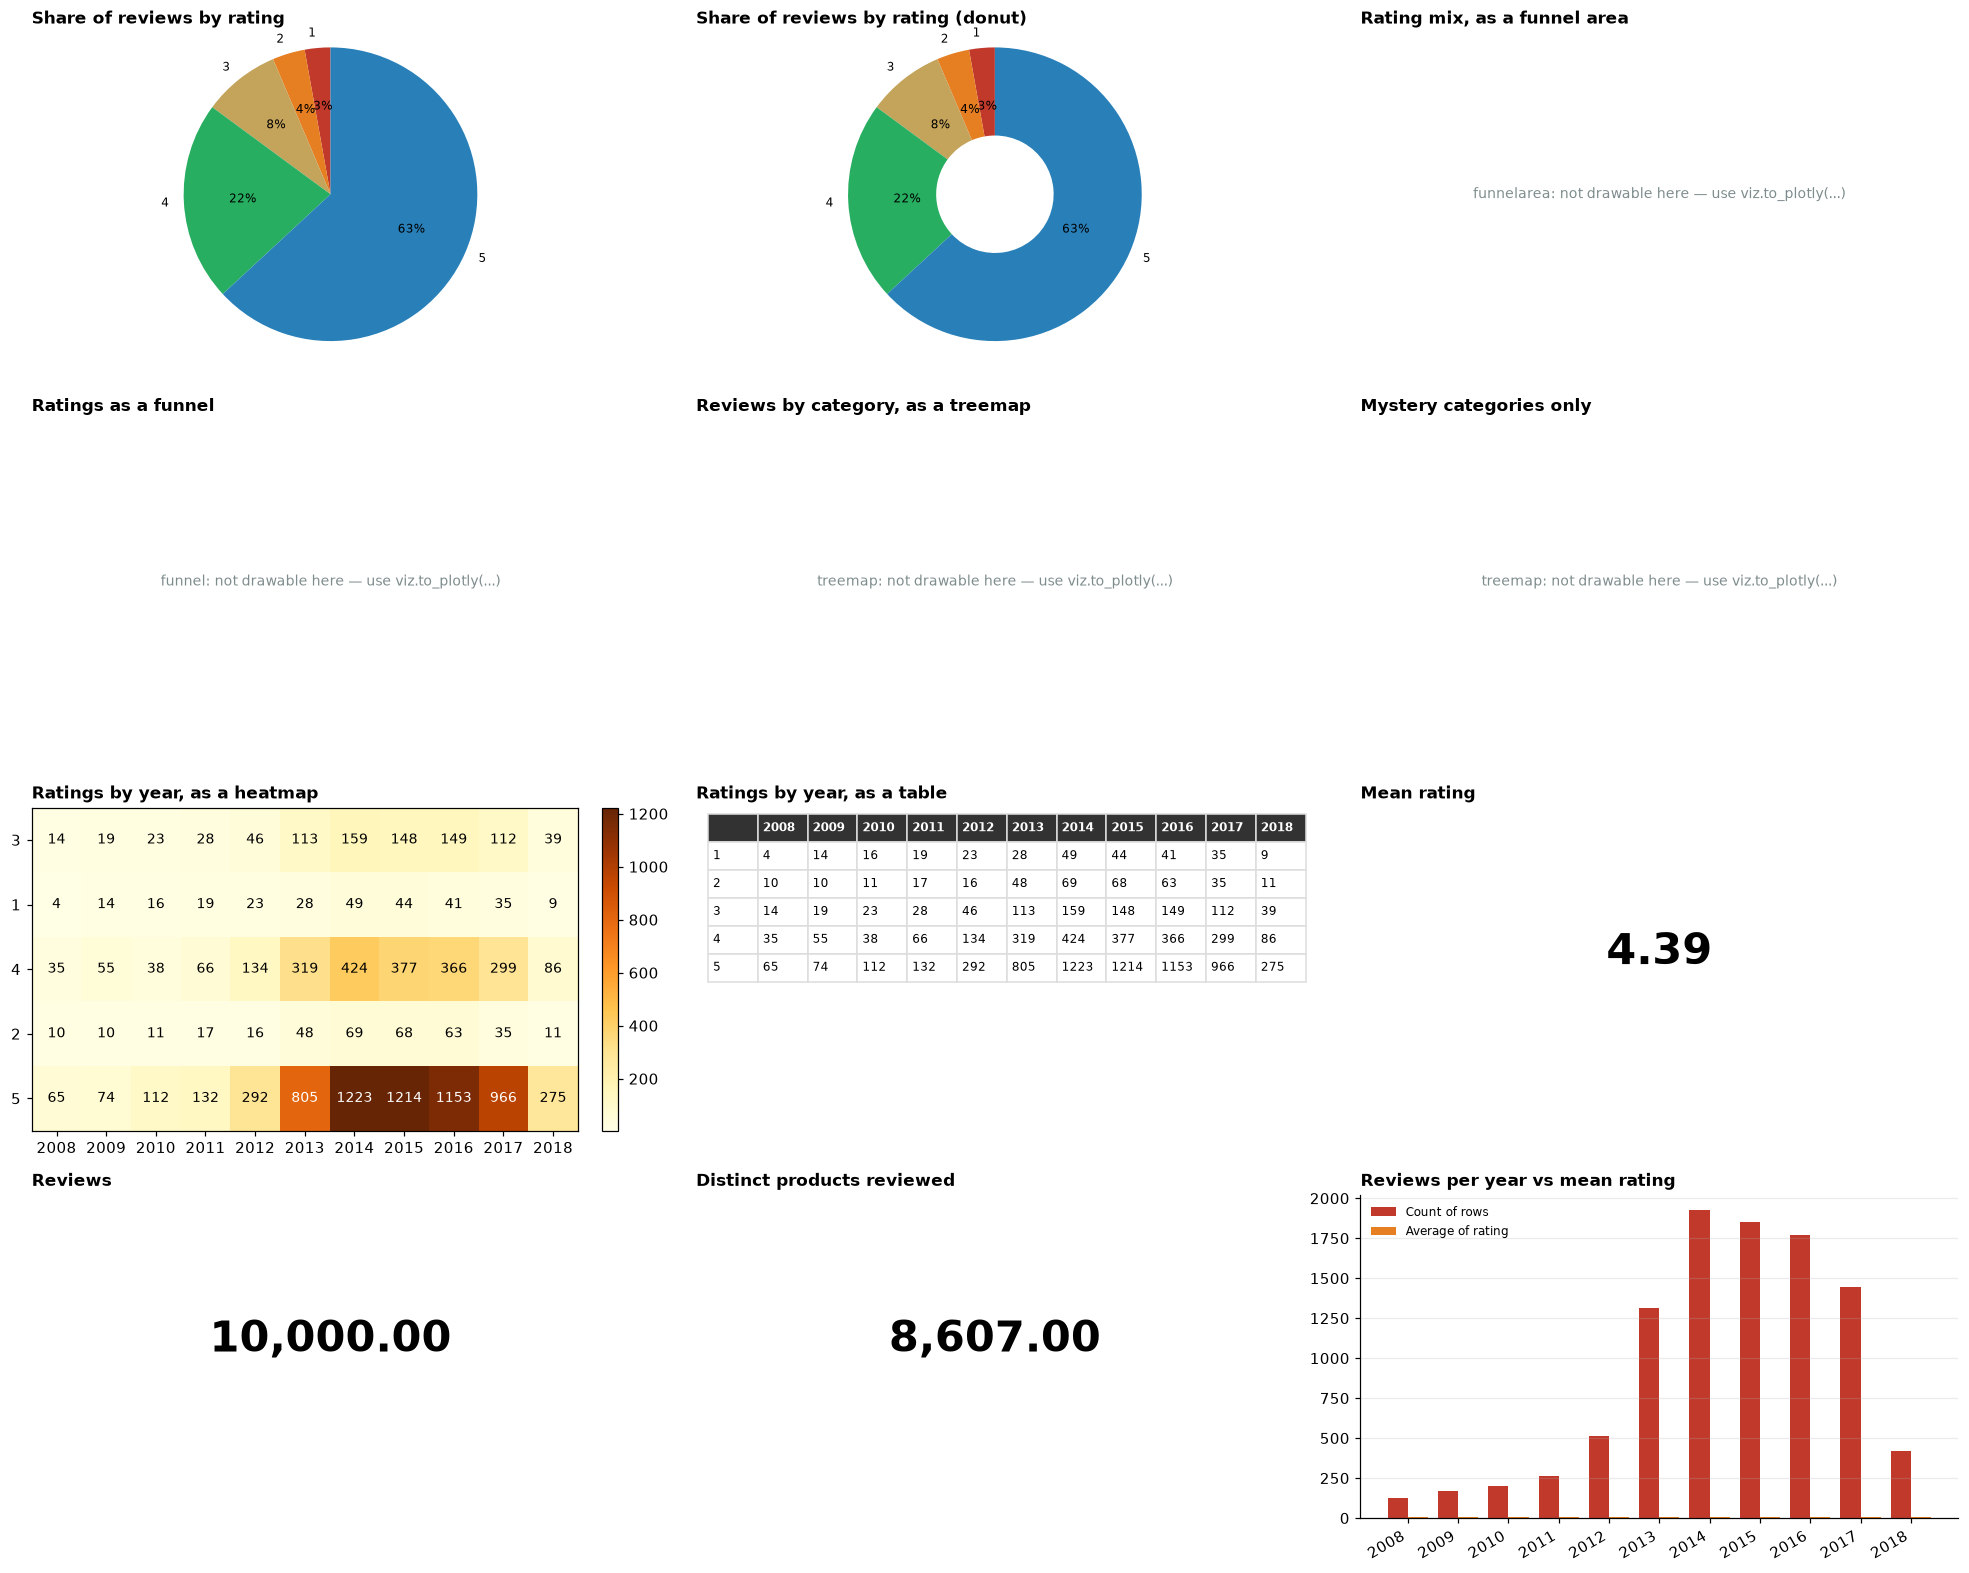

In [15]:
fig(viz.draw_tab(tab, cols=3))

In [16]:
charged = credits_used(ls) - before
built = len(tab.refresh().charts)
print(f"{built} charts · credits charged: {charged}")
print("\nwith chapters 17 and 18, the book has now drawn every chart type this server allows:")
print(" ", ", ".join(sorted(set(charts.BY_ID) - {"scatter"})))
save_metrics(".", {"notebook": "19_composition", "task": "compositions, grids, KPI and combo · the last 9 of the 24 types",
                   "model": "—", "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"charts_built": built, "treemap_leaves": pv and t and None or None,
                                "types_available_here": len(charts.BY_ID) - 1,
                                "xy_scatter_enabled": cap["xy_scatter_enabled"]}})

12 charts · credits charged: 0

with chapters 17 and 18, the book has now drawn every chart type this server allows:
  area, bar, column, combo, donut, dot, funnel, funnelarea, grouped_bar, grouped_column, heatmap, histogram, kpi, line, line_markers, matrix, pie, stacked_area, stacked_bar, stacked_bar_100, stacked_column, stacked_column_100, treemap
wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [20 · Make it readable](../20_readable/) — number formats, data labels, colours, rules, reference lines
- [21 · Measures and filters](../21_measures_and_filters/) — the semantic layer, and filtering a board
- [16 · The grammar](../16_chart_grammar/) — the 24 types, read from the server